In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib as mpl
import warnings; warnings.simplefilter('ignore')
import os
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_simload
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

from scipy.interpolate import UnivariateSpline
from scipy.optimize import brentq

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]


In [4]:
# --------------------------------------------------------------------------
# 1. Analytic NFW profile
# --------------------------------------------------------------------------
 
def mu(x):
    """NFW enclosed-mass shape function: M(<x*rs) propto mu(x)."""
    return np.log1p(x) - x / (1.0 + x)
 
 
def nfw_rho0(Mvir, rvir, c):
    """Characteristic density normalization from (Mvir, rvir, c)."""
    rs = rvir / c
    return Mvir / (4.0 * np.pi * rs**3 * mu(c))
 
 
def nfw_density(r, rho0, rs):
    x = r / rs
    return rho0 / (x * (1.0 + x) ** 2)
 
 
# --------------------------------------------------------------------------
# 2. Sample particle radii (and, optionally, 3D positions) from the NFW CDF
# --------------------------------------------------------------------------
 
def sample_nfw_radii(N, rvir, c, rng, x_min=1e-6, n_grid=20000):
    """
    Inverse-transform sampling of r via the NFW enclosed-mass profile.
    Vectorized: builds mu(x) on a log grid once, then inverts via
    interpolation for all N draws at once (fast even for N ~ 1e7).
    """
    rs = rvir / c
    x_grid = np.logspace(np.log10(x_min), np.log10(c), n_grid)
    mu_grid = mu(x_grid)
    mu_grid /= mu_grid[-1]  # normalize enclosed-mass fraction to [0, 1] at x=c
 
    u = rng.random(N)
    x = np.interp(u, mu_grid, x_grid)
    return x * rs
 
 
def sample_isotropic_positions(r, rng):
    """Give each radius r_i a random direction -> 3D positions."""
    costheta = rng.uniform(-1.0, 1.0, size=r.size)
    phi = rng.uniform(0.0, 2.0 * np.pi, size=r.size)
    sintheta = np.sqrt(1.0 - costheta**2)
    x = r * sintheta * np.cos(phi)
    y = r * sintheta * np.sin(phi)
    z = r * costheta
    return np.column_stack([x, y, z])
 
 
# --------------------------------------------------------------------------
# 3. Bin into a measured density profile
# --------------------------------------------------------------------------
 
def measure_density_profile(r, mp, edges):
    """
    Log-spaced bins in r/rvir over [xmin, xmax]. Returns bin centers
    (log-midpoint), density = (count * mp) / shell volume, and raw counts
    (so you can see/inspect Poisson noise per bin).
    """
    counts, _ = np.histogram(r, bins=edges)
    vol = (4.0 / 3.0) * np.pi * (edges[1:] ** 3 - edges[:-1] ** 3)
    rho = counts * mp / vol
    centers = np.sqrt(edges[1:] * edges[:-1])  # geometric (log) bin center
    return centers, rho, counts
 
 
# --------------------------------------------------------------------------
# 4. Recover r_s: find where dln(rho)/dln(r) = -2
# --------------------------------------------------------------------------
 
def recover_rs_from_slope(r_centers, rho, counts=None, min_counts=1, s=None):
    """
    Fit a smoothing spline to log(rho) vs log(r) (only over bins with
    rho > 0, optionally requiring a minimum particle count to reject
    empty/noise-dominated bins), differentiate it analytically, and solve
    dlogrho/dlogr(r) = -2 for r.
 
    `s` is the UnivariateSpline smoothing factor -- with real (noisy)
    binned data you generally want s > 0 (some smoothing) rather than an
    interpolating spline (s=0), which will chase Poisson noise and can
    give spurious/multiple roots. If left None, scipy picks a default;
    tune it for your bin count / particle count.
 
    Returns (rs_recovered, spline). rs_recovered is None if no root
    is found (e.g. profile is too noisy, or slope never reaches -2 over
    the fitted range) and a list of roots if multiple are found (pick the
    physically sensible one, typically the one closest to your prior on
    r_s, or the innermost one).
    """
    mask = rho > 0
    if counts is not None:
        mask &= counts >= min_counts
 
    logr = np.log(r_centers[mask])
    logrho = np.log(rho[mask])
    order = np.argsort(logr)
    logr, logrho = logr[order], logrho[order]
 
    spline = UnivariateSpline(logr, logrho, k=3, s=s)
    dspline = spline.derivative(1)
 
    f = lambda lr: dspline(lr) + 2.0
    lr_grid = np.linspace(logr.min(), logr.max(), 4000)
    vals = f(lr_grid)
 
    roots = []
    for i in range(len(vals) - 1):
        if np.isfinite(vals[i]) and np.isfinite(vals[i + 1]) and vals[i] * vals[i + 1] < 0:
            roots.append(brentq(f, lr_grid[i], lr_grid[i + 1]))
 
    if not roots:
        return None, spline
    r_roots = np.exp(roots)
    return (r_roots[0] if len(r_roots) == 1 else r_roots), spline
 

In [5]:
np.argmin(np.abs(cfg.zsample - 2.0))

171

In [10]:
def measure_c(Mvir, c_true, mp, seed=42, plot=False):

    rng = np.random.default_rng(seed)

    profile = profiles.NFW(Mvir, c_true, cfg.Dvsample[0], cfg.zsample[0])
    rsmooth = np.logspace(-1, np.log10(profile.rh), 100)
    rvir = profile.rh

    rs_true = rvir / c_true
    N_particles = int(Mvir / mp)

    # --- Sample particles ---
    r = sample_nfw_radii(N_particles, rvir, c_true, rng)

    # --- Sample particles ---
    r_3D = sample_isotropic_positions(r, rng)
    rad_bins = np.logspace(np.log10(1e-3*rvir), np.log10(rvir), 50)

    centers, rho, counts = measure_density_profile(r, mp, edges=rad_bins)
    rs_rec, spline = recover_rs_from_slope(centers, rho, counts=counts, min_counts=10, s=0.01*rad_bins.shape[0])
    c_rec = rvir / np.atleast_1d(rs_rec)[0]  # take first root if recover_rs_from_slope found several

    if plot==True:

        fig, axes = plt.subplots(2, 1, figsize=(double_textwidth, double_textwidth), sharex=True,
                                    gridspec_kw={"height_ratios": [2.5, 1]})

        axes[0].plot(rsmooth, profile.rho(rsmooth),color="k", ls="--", lw=2, label="input analytic profile")
        axes[0].axvline(rs_true, color="k", ls=":", label="true r$_s$")

        axes[0].scatter(centers, rho, marker=".", s=50, label="recovered profile")
        axes[0].axvline(rs_rec, ls=":", label="recovered r$_s$")

        # --- spline fit, evaluated over the same range as the binned points ---
        logr_fine = np.linspace(np.log(centers.min()), np.log(centers.max()), 400)
        axes[0].plot(np.exp(logr_fine), np.exp(spline(logr_fine)), color="C1", lw=1.5,
                    label="spline fit")

        axes[0].set_ylabel("$\\rho$(r) [M$_{\\odot}$ kpc$^{-3}$]")
        axes[1].set_xlabel("$r$ [kpc]")

        axes[0].legend(facecolor="white", framealpha=1, edgecolor="k")

        axes[0].set_xscale("log")
        axes[0].set_yscale("log")

        # --- bottom panel: dlnrho/dlnr from the spline ---
        dspline = spline.derivative(1)
        axes[1].plot(np.exp(logr_fine), dspline(logr_fine), color="C1", lw=1.5)
        axes[1].axhline(-2, color="k", ls=":", lw=1)
        axes[1].axvline(rs_true, color="k", ls=":")
        axes[1].axvline(rs_rec, ls=":")
        axes[1].set_ylabel("d log $\\rho$ / d log $r$")

        axes[1].set_xlim(rsmooth.min(), rsmooth.max())

        info_text = (
            rf"$M_{{\rm vir}} = {Mvir:.2e}\ M_\odot$" "\n"
            rf"$m_p = {mp:.2e}\ M_\odot$" "\n"
            rf"$N_{{\rm particles}} = {N_particles:,}$" "\n"
            rf"$c_{{\rm true}} = {c_true:.2f}$" "\n"
            rf"$c_{{\rm rec}} = {c_rec:.2f}$"
        )

        axes[1].text(0.01, 0.06, info_text, transform=axes[1].transAxes, bbox=dict(boxstyle="round", facecolor="white", alpha=1))

        plt.tight_layout()
        plt.show()

    else:
        return c_rec

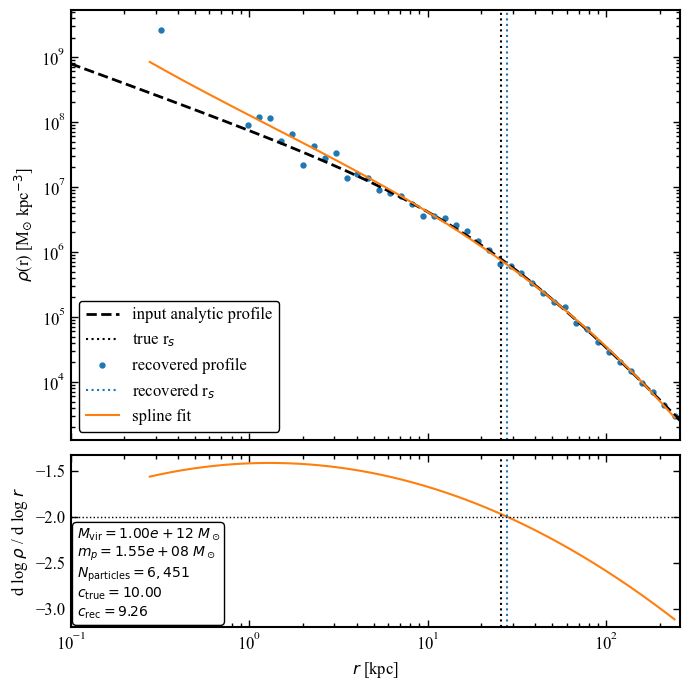

In [21]:
measure_c(Mvir=1e12, c_true=10, mp=1.55e8, seed=33, plot=True)

In [23]:
def measure_c_core(Mvir, c_true, mp, seed, min_counts=10, s=None):
    """Bare recovery, no plotting -- for Monte Carlo over seeds."""
    rng = np.random.default_rng(seed)
    profile = profiles.NFW(Mvir, c_true, cfg.Dvsample[0], cfg.zsample[0])
    rvir = profile.rh
    N_particles = int(Mvir / mp)

    r = sample_nfw_radii(N_particles, rvir, c_true, rng)
    rad_bins = np.logspace(np.log10(1e-3 * rvir), np.log10(rvir), 60)
    centers, rho, counts = measure_density_profile(r, mp, edges=rad_bins)
    rs_rec, _ = recover_rs_from_slope(centers, rho, counts=counts,
                                       min_counts=min_counts, s=s)
    if rs_rec is None:
        return np.nan
    return rvir / np.atleast_1d(rs_rec)[0]

Mvir, c_true, mp = 1e12, 9, 1.55e7
c_recs = np.array([measure_c_core(Mvir, c_true, mp, seed) for seed in range(200)])
c_recs = c_recs[np.isfinite(c_recs)]

print(f"c_true = {c_true:.2f}")
print(f"<c_rec> = {c_recs.mean():.2f} +/- {c_recs.std():.2f}  "
      f"({c_recs.std()/c_true*100:.1f}% scatter)")

c_true = 9.00
<c_rec> = 8.04 +/- 0.52  (5.8% scatter)


In [ ]:
c_recs.shape